## NNFM STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

nnfm=pd.read_csv('../stock_data/nnfm.csv') ## so it can be small letter. This is cool.
nnfm=nnfm.drop(columns=['high_price','low_price'])
nnfm.rename(columns={'trade_date':'date'},inplace=True)
nnfm['date']=pd.to_datetime(nnfm['date'])
nnfm['month']=nnfm['date'].dt.month
nnfm['quarter']=nnfm['date'].dt.quarter
nnfm['year']=nnfm['date'].dt.year

nnfm

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42796,NNFM,2017-01-03,6.01,6.01,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43356,NNFM,2017-01-04,6.01,6.01,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43466,NNFM,2017-01-05,6.01,6.01,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43576,NNFM,2017-01-06,6.01,6.01,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43666,NNFM,2017-01-09,6.01,6.01,100,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298109,NNFM,2026-07-13,79.40,79.40,4014,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298547,NNFM,2026-07-14,79.40,79.40,1986,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298985,NNFM,2026-07-15,79.40,79.40,2751,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299423,NNFM,2026-07-16,79.40,79.40,3538,2026-07-16T15:10:03.113936+00:00,7,3,2026


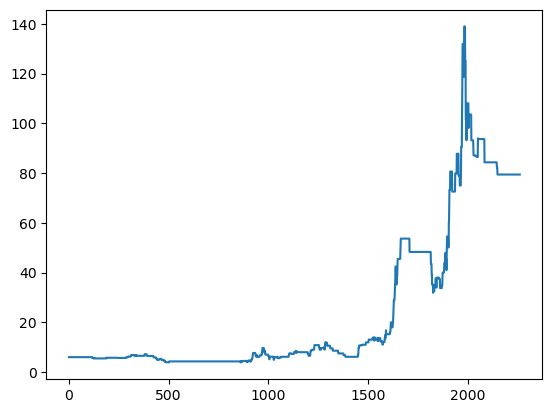

In [2]:
import matplotlib.pyplot as plt

plt.plot(nnfm['close_price'])
plt.show()

In [3]:
nnfm_end_month_df = (
    nnfm
    .sort_values("date")
    .groupby(nnfm["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

nnfm_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45366,NNFM,2017-01-31,6.01,6.01,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47187,NNFM,2017-02-28,6.01,6.01,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49303,NNFM,2017-03-31,6.01,6.01,50504,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51131,NNFM,2017-04-28,6.01,6.01,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53053,NNFM,2017-05-31,6.01,6.01,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35346,NNFM,2026-03-31,79.40,79.40,144069,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281172,NNFM,2026-04-30,79.40,79.40,5622,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284238,NNFM,2026-05-29,79.40,79.40,2942,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294166,NNFM,2026-06-30,79.40,79.40,1094,2026-06-30T15:10:03.08168+00:00,6,2,2026


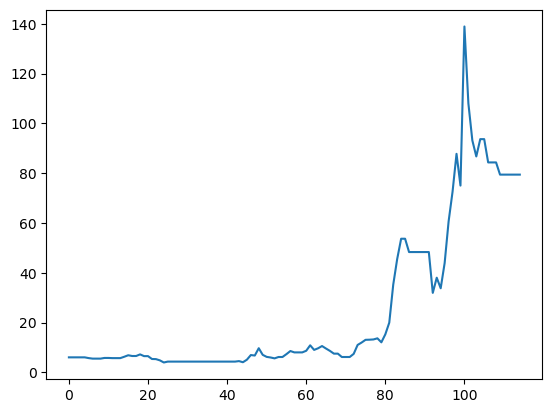

In [4]:
plt.plot(nnfm_end_month_df['close_price'])
plt.show()

In [5]:
nnfm_end_month_df['returns']=nnfm_end_month_df['close_price'].pct_change()*100
nnfm_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45366,NNFM,2017-01-31,6.01,6.01,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47187,NNFM,2017-02-28,6.01,6.01,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.0
2,49303,NNFM,2017-03-31,6.01,6.01,50504,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.0
3,51131,NNFM,2017-04-28,6.01,6.01,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.0
4,53053,NNFM,2017-05-31,6.01,6.01,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.0
...,...,...,...,...,...,...,...,...,...,...,...
110,35346,NNFM,2026-03-31,79.40,79.40,144069,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.0
111,281172,NNFM,2026-04-30,79.40,79.40,5622,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.0
112,284238,NNFM,2026-05-29,79.40,79.40,2942,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.0
113,294166,NNFM,2026-06-30,79.40,79.40,1094,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.0


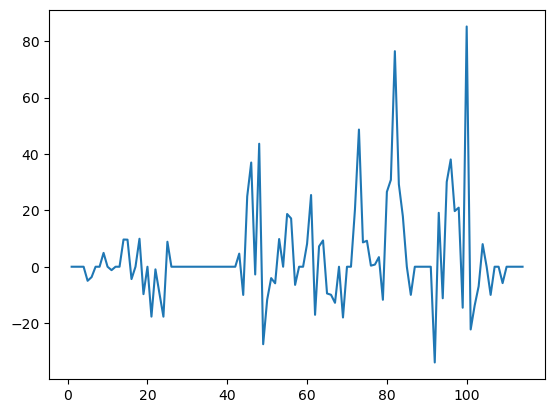

In [6]:
plt.plot(nnfm_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(nnfm_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-5.685645323928735, 8.291536349025177e-07, 1, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 862.1528020282146)
stationary


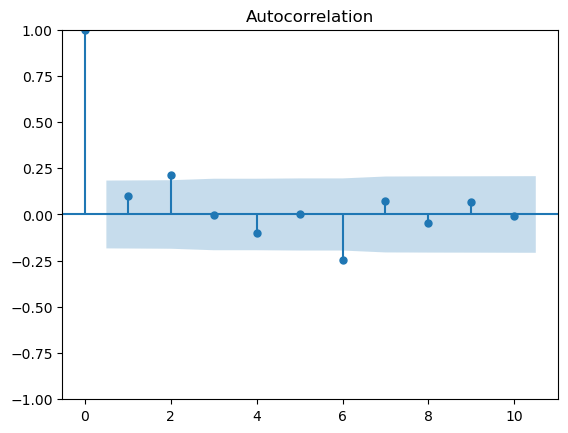

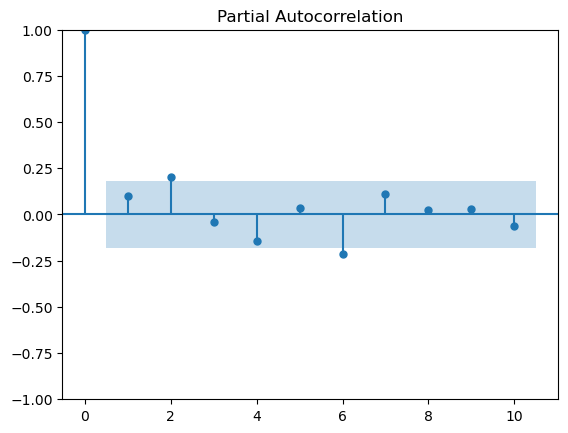

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(nnfm_end_month_df['returns'].dropna(), lags=10)
plot_pacf(nnfm_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nnfm_end_month_df['close_price'][:-10]
test=nnfm_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -354.0562192780565]
[0, 0, 0, 0, 0, 1, -156.46418053680154]
[0, 0, 0, 0, 0, 2, -159.74781230714856]
[0, 0, 0, 0, 1, 0, -64.50190882844595]
[0, 0, 0, 0, 1, 1, -135.21118559370683]
[0, 0, 0, 0, 1, 2, -145.70460047097762]
[0, 0, 0, 0, 2, 0, -223.01720494191866]
[0, 0, 0, 0, 2, 1, -200.43281225905812]
[0, 0, 0, 0, 2, 2, -206.10954882596113]
[0, 0, 0, 1, 0, 0, -62.119508701961955]
[0, 0, 0, 1, 0, 1, -124.85991034174926]
[0, 0, 0, 1, 0, 2, -130.9885253019122]
[0, 0, 0, 1, 1, 0, -150.33465344183128]
[0, 0, 0, 1, 1, 1, -152.55737414914063]
[0, 0, 0, 1, 1, 2, -135.13204999786848]
[0, 0, 0, 1, 2, 0, -200.68537080009543]
[0, 0, 0, 1, 2, 1, -201.55692816805953]
[0, 0, 0, 1, 2, 2, -209.63598769594302]
[0, 0, 0, 2, 0, 0, -114.65102165917149]
[0, 0, 0, 2, 0, 1, -130.39773329344766]
[0, 0, 0, 2, 0, 2, -130.6269306675586]
[0, 0, 0, 2, 1, 0, -152.53381206599113]
[0, 0, 0, 2, 1, 1, -151.7894854586953]
[0, 0, 0, 2, 1, 2, -151.46722254691383]
[0, 0, 0, 2, 2, 0, -203.7771657188393]
[0, 0,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-6499.987324
177,0,2,0,1,2,0,-4622.952698
169,0,2,0,0,2,1,-4436.646322
186,0,2,0,2,2,0,-4209.304450
188,0,2,0,2,2,2,-4194.590503
...,...,...,...,...,...,...,...
261,1,0,0,2,0,0,-0.305860
243,1,0,0,0,0,0,-0.259093
648,2,2,0,0,0,0,-0.113613
244,1,0,0,0,0,1,0.075735


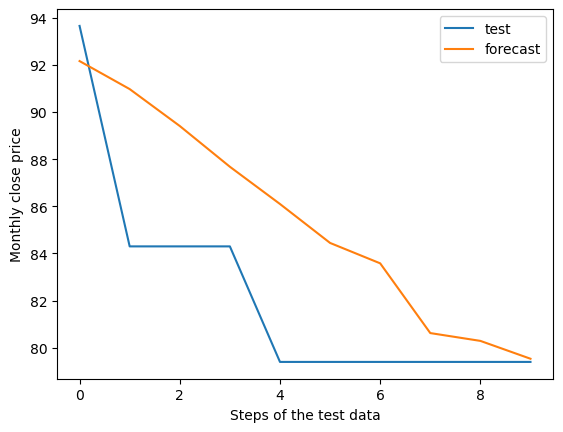

r2_score:  0.08871517889245151
rmse:  4.175076178613982
description:  count    115.000000
mean      24.638957
std       30.998520
min        3.950000
25%        5.650000
50%        7.300000
75%       40.950000
max      138.900000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=nnfm_end_month_df['close_price'][:-10]
y_test=nnfm_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,0), 
seasonal_order=(1,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nnfm_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nnfm_end_month_df['returns'].dropna()[:-10]
test=nnfm_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.22995553367347865]
[0, 0, 0, 0, 0, 1, -0.24194495564191487]
[0, 0, 0, 0, 0, 2, 0.14787126986021315]
[0, 0, 0, 0, 1, 0, -109.25073217178641]
[0, 0, 0, 0, 1, 1, -17.598254704703244]
[0, 0, 0, 0, 1, 2, -25.49936808892904]
[0, 0, 0, 0, 2, 0, -456.4384174000391]
[0, 0, 0, 0, 2, 1, -138.6490367496441]
[0, 0, 0, 0, 2, 2, -70.62648593605341]
[0, 0, 0, 1, 0, 0, -0.2424077319875937]
[0, 0, 0, 1, 0, 1, -0.24836484207281395]
[0, 0, 0, 1, 0, 2, -3.198806694827657]
[0, 0, 0, 1, 1, 0, -57.859573460162785]
[0, 0, 0, 1, 1, 1, -20.487357752070718]
[0, 0, 0, 1, 1, 2, -17.436593672186444]
[0, 0, 0, 1, 2, 0, -208.01140987919263]
[0, 0, 0, 1, 2, 1, -88.7656409152147]
[0, 0, 0, 1, 2, 2, -138.7484737790792]
[0, 0, 0, 2, 0, 0, 0.10427743399517919]
[0, 0, 0, 2, 0, 1, -0.007752885572212653]
[0, 0, 0, 2, 0, 2, -4.588880568089425]
[0, 0, 0, 2, 1, 0, -30.20991839890535]
[0, 0, 0, 2, 1, 1, -23.419405340859132]
[0, 0, 0, 2, 1, 2, -26.928085474515132]
[0, 0, 0, 2, 2, 0, -123.9777074612977]
[0, 0,

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
152,0,1,2,1,2,2,-957640.078827
168,0,2,0,0,2,0,-69018.998132
177,0,2,0,1,2,0,-27836.302158
411,1,2,0,0,2,0,-23924.795106
179,0,2,0,1,2,2,-19471.425097
...,...,...,...,...,...,...,...
45,0,0,1,2,0,0,0.369703
261,1,0,0,2,0,0,0.389430
29,0,0,1,0,0,2,0.390550
272,1,0,1,0,0,2,0.460020


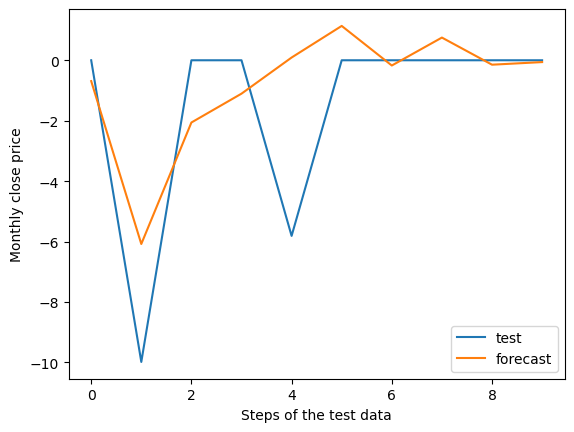

r2_score:  0.4660979852784828
rmse:  2.4069733834062204
description:  count    114.000000
mean       3.482412
std       16.964906
min      -33.954451
25%       -2.359570
50%        0.000000
75%        7.817666
max       85.200000
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=nnfm_end_month_df['returns'].dropna()[:-10]
y_test=nnfm_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,0), 
seasonal_order=(0,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nnfm_end_month_df.returns.dropna().describe())

Much better.
